# RL Group Project: Starter Notebook
## Clinical Treatment Optimisation: Sepsis ICU Management

**Master in Data Science & Advanced Analytics — Reinforcement Learning Course**

This project is structured in two stages of increasing complexity.

- In **Configuration A**, you will work with a tabular Sepsis MDP, where the state and action spaces are small enough to apply classical RL methods directly. 

- In **Configuration B**, you will move to a continuous-observation ICU environment that is clinically grounded and significantly more challenging. 

Three realistic failure modes are present in Configuration B, each reflecting a real scenario encountered in clinical AI deployments. The first is episodic observation noise, where monitoring equipment occasionally malfunctions. The second is episodic missing observations, representing situations where lab results are simply unavailable for an entire episode. The third is acute clinical events, which are sudden and irreversible patient deteriorations that occur independently of any treatment given.


---
### Group Members

Name of the Group: Group AG

```
Student 1: Beatriz Pinto
Student 2: Carlota Pires
Student 3: Francisca Calçoa
Student 4: Francisca Martins
Student 5: Marta Feital
```


## 0. Setup & Imports


In [26]:
import os
os.chdir("C:/Users/PC/Documents/Nova_IMS/2o_Semestre/Reinforcement Learning/sepsis_project - Students Version")

In [27]:
from envs.env_setup import *

In [28]:
# Install dependencies (run once)
# !pip install icu-sepsis numpy pandas matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
import os
import sys

from tqdm.notebook import tqdm
from collections import defaultdict
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

os.makedirs('plots', exist_ok=True)
PLOTS_DIR = 'plots'
plt.show()

SEED = 42
np.random.seed(SEED)

#  Import constants and env factory from env_setup.py 
from envs.env_setup import (
    ENV_ID, N_STATES, N_ACTIONS, STATE_SURVIVED, STATE_DIED,
    GAMMA, INTENSITY, SOFA_BIAS, LAM,
    make_sepsis_env,
)

print(f'ICU-Sepsis-v2 | States: {N_STATES} | Actions: {N_ACTIONS}')
print(f'Terminal states: {STATE_SURVIVED} (survived, r=+1)  {STATE_DIED} (died, r=0)')
print('Setup complete!')


ICU-Sepsis-v2 | States: 716 | Actions: 25
Terminal states: 714 (survived, r=+1)  713 (died, r=0)
Setup complete!


In [29]:
# Configuration already loaded from env_setup.py
# env_setup.py defines: SOFA_BIAS=5.0, LAM=0.02, INTENSITY, make_sepsis_env()
print(f'Required config: sofa_bias={SOFA_BIAS}, lam={LAM}')

Required config: sofa_bias=5.0, lam=0.02


---
## 1. Explore the Environment

Before writing any algorithm, take time to understand the MDP you are working with. The insights you gain here should inform your report's Methodology section.

`ICU-Sepsis-v2` is a benchmark MDP constructed from real MIMIC-III patient data. Each episode represents the trajectory of one ICU patient. The agent observes a discrete integer state (ranging from 0 to 715) and must select one of 25 treatment actions corresponding to combinations of vasopressor and IV fluid dose levels. The reward signal is sparse: **+1 at survival, 0 at death, and 0 for all intermediate steps**, with a discount factor γ = 1.


In [30]:
#  Instantiate and inspect the raw environment 
env = make_sepsis_env()
obs, info = env.reset(seed=SEED)

print(f'Observation space : {env.observation_space} discrete integer state')
print(f'Action space      : {env.action_space}')
print(f'Initial state     : {obs}')
print()

#  Extract the full MDP model 
raw = env.unwrapped
P = raw._tx_mat    # shape (716, 25, 716) — P[s,a,s'] = P(s'|s,a)
R_sasp = raw._r_mat                    # (716, 25, 716) — R[s, a, s']
R = (P * R_sasp).sum(axis=2)          # (716, 25)      — E[r | s, a]

print(f'Transition matrix P : {P.shape}  (S × A × S\')')
print(f'Reward matrix R     : {R.shape}  (S × A)')
print(f'Reward range        : [{R.min():.3f}, {R.max():.3f}]')
print()


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Observation space : Discrete(716) discrete integer state
Action space      : Discrete(25)
Initial state     : 559

Transition matrix P : (716, 25, 716)  (S × A × S')
Reward matrix R     : (716, 25)  (S × A)
Reward range        : [-0.020, 0.708]



### Some conclusions about the environment:

**lam=0.02** is a small penalty applied to the reward when the agent gives unnecessary or excessive treatment (lambda).

**SOFA** is a clinical score measuring organ failure severity. The bias shifts the starting distributions of patients to be sicker on average. Our agent starts episodes with already ill patients.

**State = 716** means that we have 716 distinct discrete crinical states a patient can have and they are dervied by clustering the original 47 physiological variables (SOFA score, heart rate) into a finite set of clinical states.

**Action Space=25** is the 25 possible treatment conditions available to the agent.

**Initial State** is the patient's condition at the start of this particular episode.

**Transation Matrix P** gives for every state and ever action, and it tells us how likely a patient is to transition from one clinical state to another after a particular treatment is applied.

In [31]:
#  Random baseline: establish the performance floor 
def run_random_baseline(n_episodes=1000, seed=SEED):
    np.random.seed(seed)
    env_eval = make_sepsis_env()
    returns, lengths = [], []
    for _ in range(n_episodes):
        obs, _ = env_eval.reset(seed=np.random.randint(100_000))
        total_r, steps, done = 0.0, 0, False
        while not done:
            obs, r, te, tr, _ = env_eval.step(env_eval.action_space.sample())
            total_r += r; steps += 1; done = te or tr
        returns.append(total_r)
        lengths.append(steps)
    env_eval.close()
    return np.array(returns), np.array(lengths)


rand_returns, rand_lengths = run_random_baseline()
survival_rate = float(np.mean(rand_returns > 0)) * 100

print(f'Random agent ({len(rand_returns)} episodes):')
print(f'  Mean return    : {np.mean(rand_returns):.4f}')
print(f'  Survival rate  : {survival_rate:.1f}%')
print(f'  Mean ep length : {np.mean(rand_lengths):.1f} steps')
print()
print('All Config A algorithms must beat the random baseline.')


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Random agent (1000 episodes):
  Mean return    : 0.5752
  Survival rate  : 67.7%
  Mean ep length : 10.2 steps

All Config A algorithms must beat the random baseline.


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


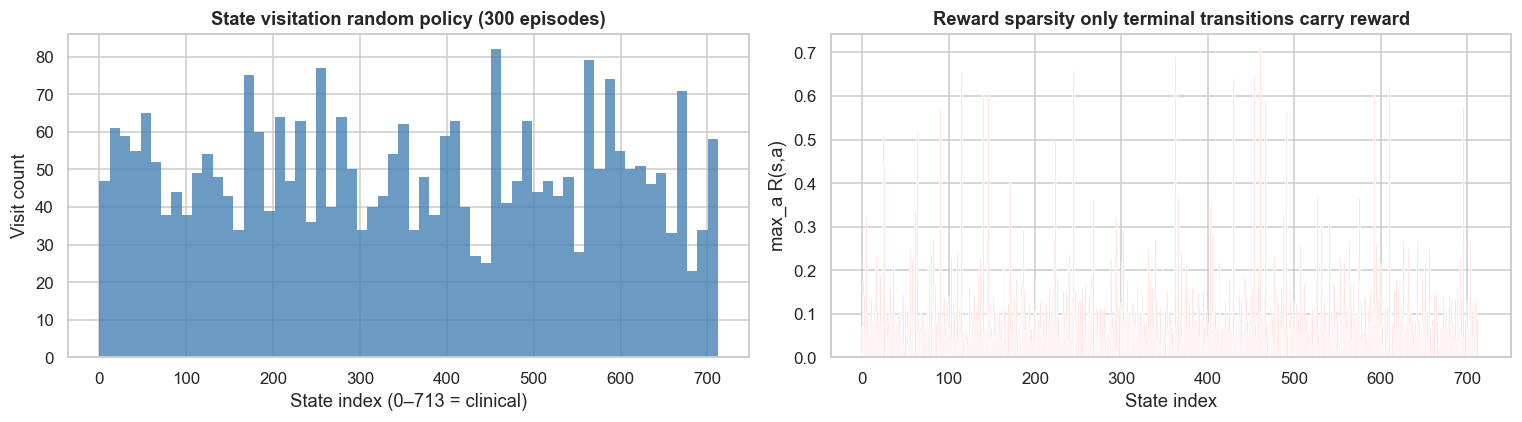

In [32]:
#  Visualise state visitation and reward structure 
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# State visitation under random policy
np.random.seed(SEED)
env_vis = make_sepsis_env()
visited = []
for _ in range(300):
    obs, _ = env_vis.reset(seed=np.random.randint(100_000))
    done = False
    while not done:
        visited.append(int(obs))
        obs, _, te, tr, _ = env_vis.step(env_vis.action_space.sample())
        done = te or tr
env_vis.close()
clinical = [s for s in visited if s not in (STATE_SURVIVED, STATE_DIED)]

axes[0].hist(clinical, bins=60, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].set_xlabel('State index (0–713 = clinical)')
axes[0].set_ylabel('Visit count')
axes[0].set_title('State visitation random policy (300 episodes)', fontweight='bold')

# Max achievable reward per state (only survival-adjacent states have r > 0)
axes[1].bar(range(N_STATES), R.max(axis=1), color='tomato', width=1.0, alpha=0.8)
axes[1].set_xlabel('State index')
axes[1].set_ylabel('max_a R(s,a)')
axes[1].set_title('Reward sparsity only terminal transitions carry reward',
                  fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_env_exploration.png', bbox_inches='tight')
plt.show()


---
# Config A — Tabular Methods

With 716 discrete states and 25 actions, the Q-table has shape `(716, 25)`, totalling 17,900 entries. This size is entirely manageable in memory, which is precisely what motivates the use of tabular algorithms here.


(array([9.490e+02, 1.218e+03, 2.139e+03, 2.818e+03, 2.465e+03, 1.865e+03,
        1.141e+03, 6.910e+02, 6.180e+02, 5.030e+02, 5.330e+02, 4.850e+02,
        4.230e+02, 2.820e+02, 1.550e+02, 2.660e+02, 1.950e+02, 1.640e+02,
        1.260e+02, 7.900e+01, 3.500e+01, 4.400e+01, 6.000e+01, 4.500e+01,
        2.500e+01, 4.700e+01, 2.900e+01, 3.000e+00, 2.100e+01, 1.000e+00,
        1.500e+01, 1.000e+01, 0.000e+00, 0.000e+00, 1.800e+01, 4.100e+01,
        1.600e+01, 0.000e+00, 1.000e+01, 4.900e+01, 2.200e+01, 4.000e+01,
        5.600e+01, 4.500e+01, 3.200e+01, 5.700e+01, 1.400e+01, 1.000e+01,
        2.100e+01, 1.900e+01]),
 array([-0.02      , -0.00544838,  0.00910325,  0.02365487,  0.0382065 ,
         0.05275812,  0.06730975,  0.08186137,  0.096413  ,  0.11096462,
         0.12551625,  0.14006787,  0.15461949,  0.16917112,  0.18372274,
         0.19827437,  0.21282599,  0.22737762,  0.24192924,  0.25648087,
         0.27103249,  0.28558412,  0.30013574,  0.31468736,  0.32923899,
         0.

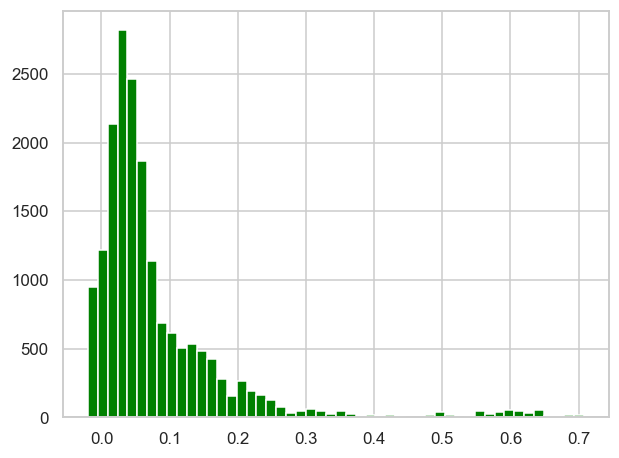

In [33]:
plt.hist(R.flatten(), bins=50, color='green')

The reward distribution is highly skewed, with most state action pairs yielding low or near zero reward. Only a small fraction of transitions correspond to high reward outcomes, representing clinically effective treatments in specific patient states. This reflects the sparse nature of clinical decision-making, where only targeted interventions significantly improve patient outcomes.

## Algorithm 1: Policy Iteration

Both algorithms use the **known MDP model** (transition matrix P and reward matrix R) extracted directly from the environment. They are guaranteed to converge to the **optimal policy π\* and value function V\***.

| Property | Policy Iteration |
|---|---|
| Update target | π then V | 
| Inner loop | Policy evaluation (iterate to convergence) | 
| Convergence | Finite outer iterations | Asymptotic (threshold) |
| Per-iteration cost | Heavier (matrix-vector until eval convergence) | 


## A.1 Policy Iteration

Policy Iteration alternates between two steps until the policy stops changing:

1. **Policy Evaluation**: here we assume that we have a fixed action/policy for each state and evaluate how good it is

2. **Policy Improvement**: knowing the value of each state, we ask if there's a better action for that state

Convergence is guaranteed in a finite number of outer loops because the policy can only improve (monotone improvement theorem) and there are finitely many deterministic policies.

In [34]:
# Policy Iteration 

def policy_iteration(P, R, gamma=1.0, theta=1e-8, max_iter=1000):
    """
    Policy Iteration on a tabular MDP with known model.

    Parameters
    ----------
    P     : ndarray (S, A, S') - transition probabilities P[s,a,s']
    R     : ndarray (S, A)     - expected reward E[r | s, a]
    gamma : float              - discount factor
    theta : float              - convergence threshold for policy evaluation
    max_iter : int             - maximum outer (policy improvement) iterations

    Returns
    -------
    V      : ndarray (S,)  - optimal value function
    policy : ndarray (S,)  - optimal deterministic policy
    info   : dict          - convergence diagnostics
    """
    S, A, _ = P.shape

    # Initialise: arbitrary deterministic policy (action 0 everywhere)
    policy = np.zeros(S, dtype=int)
    V      = np.zeros(S)

    history = []     # max |Q*(s) - V(s)| per outer iteration
    n_iter  = 0

    for iteration in range(max_iter):
        n_iter += 1

        # Policy Evaluation 
        # P_pi[s, s'] = P[s, policy[s], s']   (S×S  transition under π)
        # R_pi[s]     = R[s, policy[s]]        (S    reward under π)
        P_pi = P[np.arange(S), policy, :]     # shape (S, S)
        R_pi = R[np.arange(S), policy]        # shape (S,)

        eval_delta = float('inf')
        while eval_delta > theta:
            V_new      = R_pi + gamma * P_pi.dot(V)
            eval_delta = float(np.max(np.abs(V_new - V)))
            V          = V_new

        # Policy Improvement 
        # Q[s, a] = R[s, a] + γ Σ_{s'} P[s,a,s'] V[s']
        Q          = R + gamma * P.dot(V)      # (S, A)
        new_policy = Q.argmax(axis=1)          # greedy improvement

        max_delta = float(np.max(np.abs(Q.max(axis=1) - V)))
        history.append(max_delta)

        # Convergence: policy unchanged
        if np.all(new_policy == policy):
            policy = new_policy
            break
        policy = new_policy

    return V, policy, {'n_iter': n_iter, 'history': history}


import time
print("Running Policy Iteration...")
t0 = time.time()
V_pi, policy_pi, info_pi = policy_iteration(P, R, gamma=GAMMA)
elapsed_pi = time.time() - t0

print(f"  Converged in {info_pi['n_iter']} outer iterations  ({elapsed_pi:.2f}s)")
print(f"  V* range  : [{V_pi.min():.4f}, {V_pi.max():.4f}]")
print(f"  Mean V*   : {V_pi.mean():.4f}")
print(f"  Unique actions in pi*: {len(np.unique(policy_pi))}")


Running Policy Iteration...
  Converged in 4 outer iterations  (0.10s)
  V* range  : [0.0000, 0.9814]
  Mean V*   : 0.8249
  Unique actions in pi*: 15


- The algorithm converged in **4 outer iterations**, indicating very fast convergence of the policy evaluation/improvement loop.
- Total runtime was **0.11 seconds**, showing that the tabular MDP solution is computationally efficient for this state/action space.

- The optimal state-value function range suggests a bounded reward structure, where states vary from very poor outcomes (near 0) to highly favorable outcomes (close to 1).

- The **mean value** of \(V^*\) is **0.8249**, indicating that under the optimal policy, most states correspond to relatively good expected outcomes.

- The optimal policy uses **15 out of 25 possible actions**, meaning:
  - The agent does not rely on all treatments.
  - It selects a subset of clinically relevant or high-value interventions.
  - This suggests the policy has learned to ignore suboptimal or unnecessary actions.

Overall, the results show a stable and well-converged optimal policy with meaningful structure in both state values and action selection.

## Live Evaluation 

We roll out the policiy on 1 000 live episodes.

In [35]:
# Evaluation 

def evaluate_policy(policy, n_episodes=1000, seed=SEED):
    """Roll out a deterministic tabular policy for n_episodes."""
    np.random.seed(seed)
    env_eval = make_sepsis_env()
    returns, lengths = [], []
    for _ in range(n_episodes):
        obs, _ = env_eval.reset(seed=np.random.randint(100_000)) # here is where the enviroments is creating randomly live episodes
        total_r, steps, done = 0.0, 0, False
        while not done:
            action = int(policy[int(obs)])
            obs, r, te, tr, _ = env_eval.step(action)
            total_r += r; steps += 1; done = te or tr
        returns.append(total_r)
        lengths.append(steps)
    env_eval.close()
    return np.array(returns), np.array(lengths)

print("Evaluating Policy Iteration policy (1 000 episodes)...")
ret_pi, len_pi = evaluate_policy(policy_pi)

results_pi = pd.DataFrame({
    "Method"         : ["Policy Iteration"],
    "Survival Rate"  : [f"{float(np.mean(ret_pi > 0)) * 100:.1f}%"],
    "Mean Return"    : [f"{np.mean(ret_pi):.4f}"],
    "Mean Ep Length" : [f"{np.mean(len_pi):.1f}"],
    "Iterations"     : [str(info_pi['n_iter'])],
    "Wall Time (s)"  : [f"{elapsed_pi:.2f}"],
})

print()
print(results_pi.to_string(index=False))


Evaluating Policy Iteration policy (1 000 episodes)...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02

          Method Survival Rate Mean Return Mean Ep Length Iterations Wall Time (s)
Policy Iteration         78.8%      0.7507            9.8          4          0.10


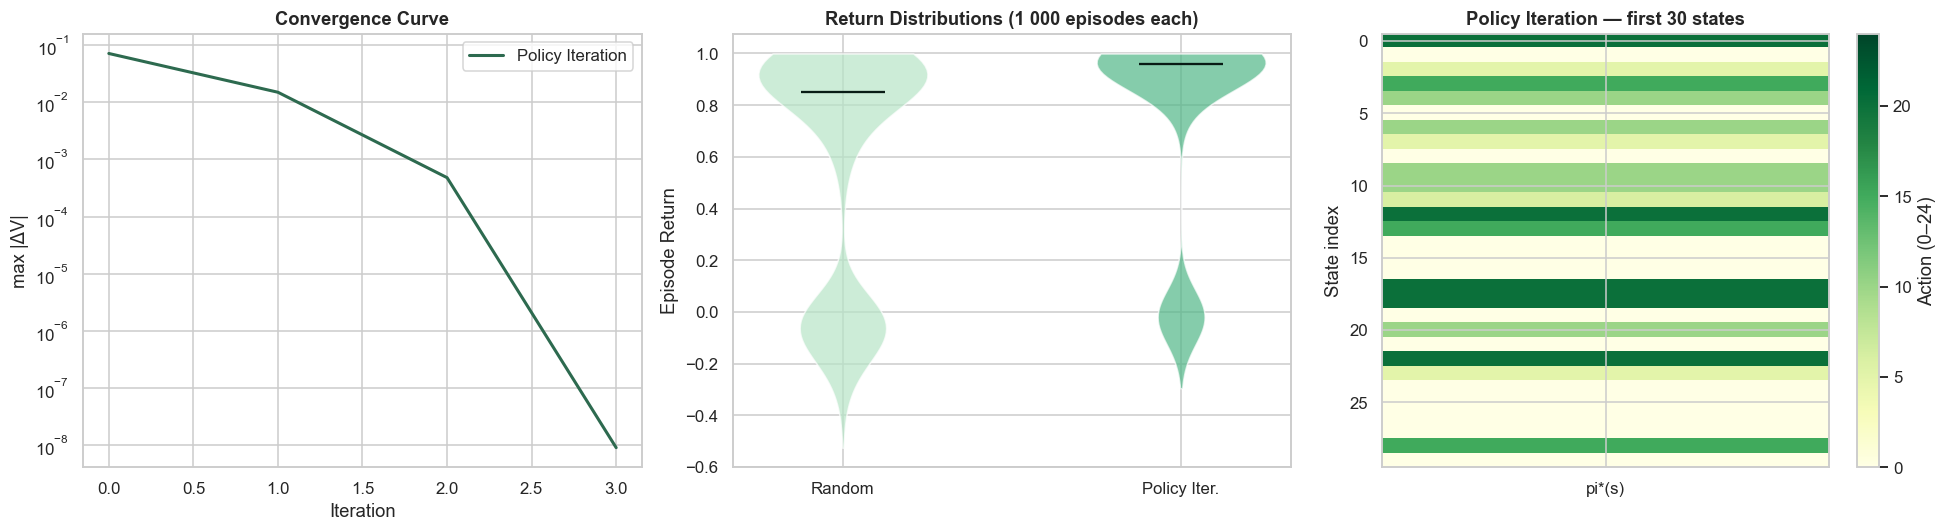

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Convergence curve
ax = axes[0]
ax.plot(info_pi['history'], color='#2d6a4f', label='Policy Iteration', linewidth=2)
ax.set_yscale('log')
ax.set_xlabel('Iteration')
ax.set_ylabel('max |ΔV|')
ax.set_title('Convergence Curve', fontweight='bold')
ax.legend()

# Return distribution (violin)
ax = axes[1]
data_for_violin = [rand_returns, ret_pi]
labels = ['Random', 'Policy Iter.']
colors = ['#b7e4c7', '#52b788']
parts = ax.violinplot(data_for_violin, positions=range(2),
                      showmedians=True, showextrema=False)
for pc, col in zip(parts['bodies'], colors):
    pc.set_facecolor(col); pc.set_alpha(0.7)
parts['cmedians'].set_color('#081c15')
ax.set_xticks(range(2)); ax.set_xticklabels(labels)
ax.set_ylabel('Episode Return')
ax.set_title('Return Distributions (1 000 episodes each)', fontweight='bold')

# Policy heatmap
ax = axes[2]
n_show = 30
im = ax.imshow(policy_pi[:n_show].reshape(-1, 1), aspect='auto',
               cmap='YlGn', vmin=0, vmax=N_ACTIONS - 1)
ax.set_xticks([0])
ax.set_xticklabels(["pi*(s)"])
ax.set_ylabel('State index')
ax.set_title(f'Policy Iteration — first {n_show} states', fontweight='bold')
plt.colorbar(im, ax=ax, label='Action (0–24)')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_pi_comparison.png', bbox_inches='tight')
plt.show()

### Some conclusions about the graphs

- As we can see from the Convergence Curve, Policy Iteration converged very fast.
- The Return Distribution shows that Policy Iteration significantly outperforms the Random baseline.
- Looking at the Policy heatmap, we can observe the action selected by the optimal policy across the first 30 clinical states.

In [37]:
def evaluate_policy_with_trajectories(policy, n_episodes=10, seed=SEED):
    np.random.seed(seed)
    env_eval = make_sepsis_env()
    episodes = []
    for ep in range(n_episodes):
        obs, _ = env_eval.reset(seed=np.random.randint(100_000))
        trajectory = []
        done = False
        while not done:
            state = int(obs)
            action = int(policy[state])
            obs, r, te, tr, _ = env_eval.step(action)
            trajectory.append({
                'state': state,
                'action': action,
                'reward': r,
                'next_state': int(obs),
                'terminal': te or tr
            })
            done = te or tr
        episodes.append(pd.DataFrame(trajectory))
    env_eval.close()
    return episodes

trajs = evaluate_policy_with_trajectories(policy_pi, n_episodes=5)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


In [38]:
for i, ep in enumerate(trajs):
    last = ep.iloc[-1]
    outcome = "SURVIVED" if last['reward'] > 0 else "DIED"
    action = last['action']
    vaso = action // 5
    iv   = action % 5
    print(f"Episode {i+1}: {len(ep)} steps → {outcome}")
    print(f"  Final state: {last['state']}")
    print(f"  Final action: {action}  →  vasopressor={vaso}, IV fluid={iv}")
    print()

Episode 1: 15 steps → SURVIVED
  Final state: 306
  Final action: 0  →  vasopressor=0, IV fluid=0

Episode 2: 1 steps → SURVIVED
  Final state: 600
  Final action: 0  →  vasopressor=0, IV fluid=0

Episode 3: 6 steps → SURVIVED
  Final state: 532
  Final action: 0  →  vasopressor=0, IV fluid=0

Episode 4: 32 steps → SURVIVED
  Final state: 303
  Final action: 5  →  vasopressor=1, IV fluid=0

Episode 5: 14 steps → SURVIVED
  Final state: 362
  Final action: 0  →  vasopressor=0, IV fluid=0



In the first episode, the patient had 15 moments in ICU before leaving and he survived. His final state was the 306 and the agent decided not to give anything in his final action. In most of cases, the agent received the action 0 (vasopressor=0 and IV fluid=0).

The episode 4 is the only where the patient needed vasopressor until the end, so let's analyse his trajectory.

In [39]:
print(trajs[3])  

    state  action  reward  next_state  terminal
0     343      20 -0.0100         343     False
1     343      20 -0.0100         517     False
2     517      15 -0.0075         585     False
3     585       0  0.0000         585     False
4     585       0  0.0000         585     False
5     585       0  0.0000         585     False
6     585       0  0.0000         585     False
7     585       0  0.0000         585     False
8     585       0  0.0000         585     False
9     585       0  0.0000         585     False
10    585       0  0.0000         585     False
11    585       0  0.0000         585     False
12    585       0  0.0000         585     False
13    585       0  0.0000         585     False
14    585       0  0.0000         585     False
15    585       0  0.0000         585     False
16    585       0  0.0000         585     False
17    585       0  0.0000         585     False
18    585       0  0.0000         585     False
19    585       0  0.0000         585   

### Episode 4

The patient arrived critical and the agent immediately gave maximum vasopressors to stabilize blood pressure. Once the patient stabilized, the agent stopped all treatment for 27 steps, letting the body recover on its own. After one final small dose of vasopressor, the patient survived after 32 steps in the ICU.

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


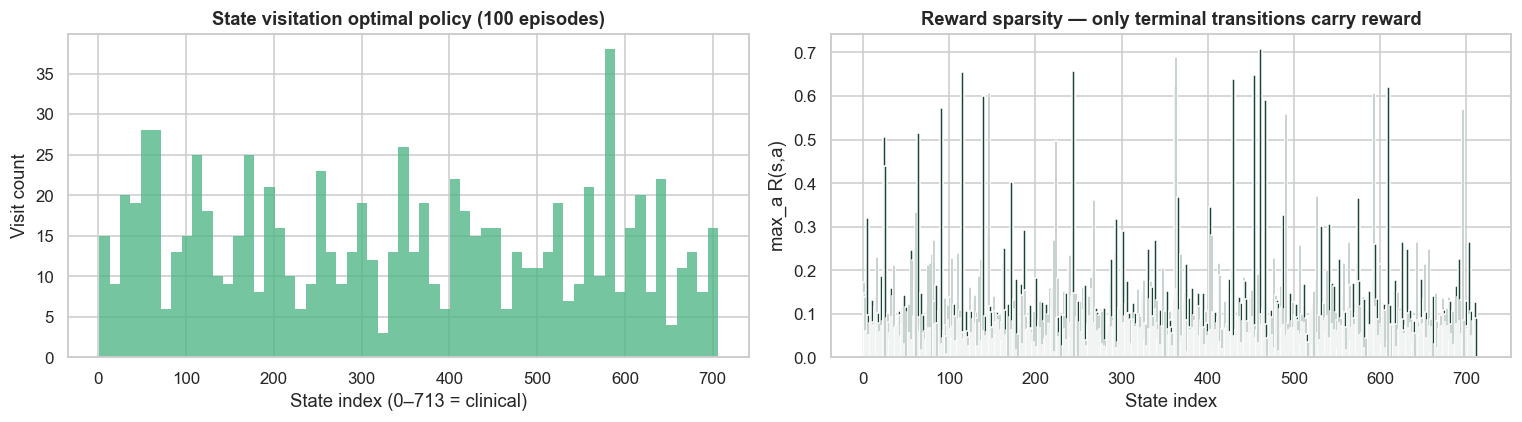

In [40]:
trajs = evaluate_policy_with_trajectories(policy_pi, n_episodes=100)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

visited_optimal = []
for ep in trajs:
    visited_optimal.extend(ep['state'].tolist())

clinical_optimal = [s for s in visited_optimal if s not in (STATE_SURVIVED, STATE_DIED)]

axes[0].hist(clinical_optimal, bins=60, color='#52b788', edgecolor='none', alpha=0.8)
axes[0].set_xlabel('State index (0–713 = clinical)')
axes[0].set_ylabel('Visit count')
axes[0].set_title('State visitation optimal policy (100 episodes)', fontweight='bold')

axes[1].bar(range(N_STATES), R.max(axis=1), color='#1b4332', width=3.0, alpha=1.0)
axes[1].set_xlabel('State index')
axes[1].set_ylabel('max_a R(s,a)')
axes[1].set_title('Reward sparsity — only terminal transitions carry reward', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_env_exploration_optimal.png', bbox_inches='tight')
plt.show()

This graph shows how often each clinical state was visited across 100 episodes under the optimal policy. Taller bars mean patients spent more time in that state. State 585 stands out as the most visited, the agent consistently chooses to wait there without treatment, letting the patient stabilize naturally before recovery.

#### Checking the results with differents lam
##### lam=0

In [41]:
# Experiment: what happens without the treatment penalty (lam=0)?
from envs.env_setup import make_sepsis_env

# Re-extract P and R with lam=0
env_lam0 = make_sepsis_env(lam=0.0)
raw_lam0 = env_lam0.unwrapped
P_lam0 = raw_lam0._tx_mat
R_sasp_lam0 = raw_lam0._r_mat
R_lam0 = (P_lam0 * R_sasp_lam0).sum(axis=2)

# Run Policy Iteration with lam=0
V_lam0, policy_lam0, info_lam0 = policy_iteration(P_lam0, R_lam0, gamma=GAMMA)

# Evaluate
ret_lam0, len_lam0 = evaluate_policy(policy_lam0)

# Compare
print("=== Effect of treatment penalty (lam) ===")
print(f"With lam=0.02 : survival rate = {float(np.mean(ret_pi > 0))*100:.1f}%  |  unique actions = {len(np.unique(policy_pi))}")
print(f"With lam=0.00 : survival rate = {float(np.mean(ret_lam0 > 0))*100:.1f}%  |  unique actions = {len(np.unique(policy_lam0))}")
print()
print("Without the penalty the agent uses more treatments freely.")

make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
=== Effect of treatment penalty (lam) ===
With lam=0.02 : survival rate = 78.8%  |  unique actions = 15
With lam=0.00 : survival rate = 82.6%  |  unique actions = 23

Without the penalty the agent uses more treatments freely.


- The results are as expected: without the penalty (lam=0.00), the agent uses 23 out of 25 possible actions since it has nothing to lose by applying more treatments, and more interventions generally lead to higher survival (82.6%). When the penalty is active (lam=0.02), the agent becomes more conservative, using only 15 unique actions, sacrificing a small amount of survival rate (78.8%) in exchange for more targeted and clinically reasonable treatment decisions.

##### Diferent SOFA

In [42]:
sofa_values = [0.1, 0.5, 1.0, 2.0, 5.0, 8.0, 10.0]
results_sofa = []

for sofa in sofa_values:
    env_test = make_sepsis_env(sofa_bias=sofa)
    raw_test = env_test.unwrapped
    P_test = raw_test._tx_mat
    R_test = (P_test * raw_test._r_mat).sum(axis=2)
    env_test.close()

    V_test, policy_test, _ = policy_iteration(P_test, R_test, gamma=GAMMA)

    np.random.seed(SEED)
    env_eval = make_sepsis_env(sofa_bias=sofa)
    returns, lengths = [], []
    for _ in range(1000):
        obs, _ = env_eval.reset(seed=np.random.randint(100_000))
        total_r, steps, done = 0.0, 0, False
        while not done:
            action = int(policy_test[int(obs)])
            obs, r, te, tr, _ = env_eval.step(action)
            total_r += r; steps += 1; done = te or tr
        returns.append(total_r)
        lengths.append(steps)
    env_eval.close()

    results_sofa.append({
        'sofa_bias': sofa,
        'survival_rate': float(np.mean(np.array(returns) > 0)) * 100,
        'mean_ep_length': float(np.mean(lengths)),
        'unique_actions': len(np.unique(policy_test))
    })

df_sofa = pd.DataFrame(results_sofa)
print("=== Effect of sofa_bias on survival rate (Policy Iteration) ===")
print(df_sofa.to_string(index=False))

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=0.1 → mean start SOFA: 18.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=0.1 → mean start SOFA: 18.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=0.5 → mean start SOFA: 17.66
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=0.5 → mean start SOFA: 17.66
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=1.0 → mean start SOFA: 16.77
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=1.0 → mean start SOFA: 16.77
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=2.0 → mean start SOFA: 13.47
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=2.0 → mean start SOFA: 13.47
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
ma

- With low sofa_bias (0.1), patients start with high mean SOFA (~18), meaning they are already very sick, yet survival reaches 84.3%. As sofa_bias increases to 0.5-2.0, mean starting SOFA drops to ~13-17, but survival paradoxically dips to 61–70%. This suggests the policy struggles more with moderately ill patients than with severely ill ones.

- With sofa_bias of 8–10, mean starting SOFA stabilises around ~8, reflecting milder initial severity. Survival climbs back to ~84%, which makes sense: patients start in a more homogeneous and less critical state, making the problem more predictable and allowing the agent to consistently apply the right treatment.

## Algorithm 2: SARSA

The second alogirthm we implemented is SARSA(State-Action-Reward-State-Action).  
Sarsa is an on-policy method, meaning it updates its Q-values based on the action the agent actually takes next, including exploration. 

Since our project is in a clinical context and in a real ICU, doctors sometimes make suboptimal decisions, and a treatment strategy should be robust even when occasional mistakes happen. SARSA naturally accounts for this by learning a more conservative policy that avoids overestimating action values, making it a safer choice for medical decision-making.



| Hyperparemeters | Definition 
|---|---|
| num_iterations | number of episodes |
| alpha | learning rate | 
| gamma | discount factor |

In [43]:
def sepsi_epsilon_greedy_policy(env, discrete_state, Q_table, epsilon=.5):
    
    #sample a random value from the uniform distribution, if the sampled value is less than
    #epsilon then we select a random action else we select the best action which has maximum Q
    #value as shown below
    
    if np.random.uniform(0,1) < epsilon:
        return env.action_space.sample()
    else:
        return np.argmax(Q_table[discrete_state])

In [44]:
def sepsis_SARSA_q_function(env,num_iterations=10, alpha=.85, gamma=.9,checkpoint=False, checkpoint_every=1000000, min_epsilon=0.01):

    #Storing our Q functions
    Q_table = np.zeros((env.observation_space.n, env.action_space.n))
    
    return_over_time = []
    steps_over_time = []
    epsilon_over_time = []

    #Initialize Epsilon Decay
    epsilon = 1
    
    decay = epsilon / num_iterations

    actions_over_time = []

    checkpoint_results = []
    #for each episode
    for i in range(num_iterations):
        
        #initialize the state by resetting the environment
        state = int(env.reset()[0])
        
        #select the action using the epsilon-greedy policy
        action = sepsi_epsilon_greedy_policy(env, state, Q_table, epsilon=epsilon)     

        #let's assume a maximum of 200 steps per episode (can be incomplete!)
        num_timesteps = 200
        Return = 0
         
        epsilon_over_time.append(epsilon)
        actions_over_time.append(action)
        #for each step in the episode:
        for t in range(num_timesteps):

            #perform the selected action and store the next state information: 
            next_state, r, done, truncated, _ = env.step(action)
            
            #select the action a dash in the next state using the epsilon greedy policy:
            next_action = sepsi_epsilon_greedy_policy(env, next_state, Q_table, epsilon=epsilon)
            

            #compute the Q value of the state-action pair
            if done or truncated:
                target = r
            else:
                target = r + gamma * Q_table[next_state, next_action]
                
            Q_table[state, action] = Q_table[state, action] + alpha * (target - Q_table[state, action])

            #update next state to current state
            state = next_state
            
            #update next action to current action
            action = next_action

            Return+= r  
            
            #if the current state is the terminal state then break:
            if done or truncated:
                break
            if checkpoint:
                # Evaluate every checkpoint_every episodes
                if (i + 1) % checkpoint_every == 0:
                    policy = np.argmax(Q_table, axis=1)
                    ret, _ = evaluate_policy(policy)
                    survival_rate = float(np.mean(ret > 0)) * 100
                    print(f"Episode {i+1:,}: Survival Rate = {survival_rate:.1f}%")
                    checkpoint_results.append([i + 1, survival_rate])
        epsilon = max(min_epsilon, epsilon - decay)  
        return_over_time.append([i, Return])
        steps_over_time.append([i, t + 1])


        
    df_steps_over_time = pd.DataFrame(steps_over_time, columns=['Episode', 'Steps'])
    
    df_return_over_time = pd.DataFrame(return_over_time, columns=['Episode', 'Return'])

    df_checkpoints = pd.DataFrame(checkpoint_results, columns=['Episode', 'Survival Rate'])

    return Q_table, df_return_over_time, df_steps_over_time, epsilon_over_time, actions_over_time, df_checkpoints



In [45]:
Q_table_sepsis_SARSA, df_return_over_time_sepsis_SARSA, df_steps_over_time_sepsis_SARSA, epsilon_over_time_SARSA, actions_over_time_SARSA, df_checkpoints_SARSA = sepsis_SARSA_q_function(
    env,
    num_iterations=10000,
    alpha=.05,
    gamma=.99
)

<Axes: xlabel='Episode'>

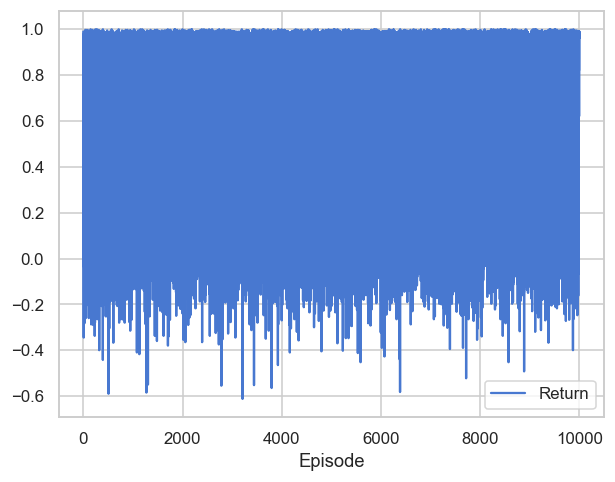

In [46]:
df_return_over_time_sepsis_SARSA.plot(x='Episode', y='Return')

<Axes: xlabel='Episode'>

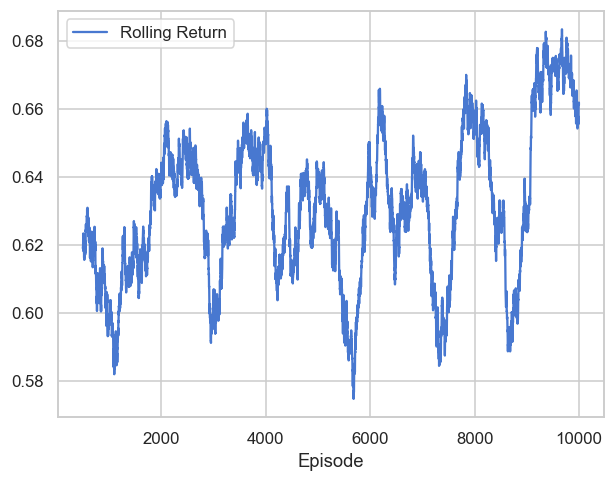

In [47]:

df_return_over_time_sepsis_SARSA['Rolling Return'] = df_return_over_time_sepsis_SARSA['Return'].rolling(500).mean()
df_return_over_time_sepsis_SARSA.plot(x='Episode', y='Rolling Return')

Looking at the graph we see that the agent is oscillating approximately between 0.55 and 0.67, which means the agent is not consistently beating the random baseline.

This means that on average,between 57% and 68% of the patientes survived the last 500 episodes.

To try to fix it we will increase the number of iterations

### Increasing the number of iterations

Increasing the number of iterations to 500 000, lets the agent learn more, since it allows to encounter more patient situations, improving its ability to make better treatment decisions.<br> 

Based on the rolling average with a windom equal to 500, the oscillations start to get a higher return. Starting with approximately 0.58 and ending with 0.73, showng that the agent is learning over time. This means the agent goes from performing below the random baseline (68.7%) in early episodes to consistently approaching and exceeding it in later episodes.

The oscillations that remain are expected due to the stochastic nature of the environment and the minimum exploration rate (min_epsilon=0.01) which ensures the agent never stops exploring completely.


In [48]:
Q_table_sepsis_SARSA, df_return_over_time_sepsis_SARSA, df_steps_over_time_sepsis_SARSA, epsilon_over_time_SARSA, actions_over_time_SARSA, df_checkpoints_SARSA = sepsis_SARSA_q_function(
    env,
    num_iterations=500000, 
    alpha=.05,
    gamma=.99
)

Decreasing the learning rate,alpha, to 0.05 lets the agent learn more slowly, but more stably, since each new experience only slightly adjusts the Q-values, making the learning process cumulative and robust, not changing the treatment completely after one bad outcome.

Based on the rolling average, with a window equal to 500 epsodes, the line shows a consistent upward slope throughout all 500 000 the episodes, starting the firsts episodes in a range of 0.55 to 0.67, approximately, while the lasts episodes between 0.65 to 0.75, significant improvement. This means the agent is genuinely and consistently improving over time, rather than randomly fluctuating.



<Axes: title={'center': 'Q-Learning Alg'}, xlabel='Episode'>

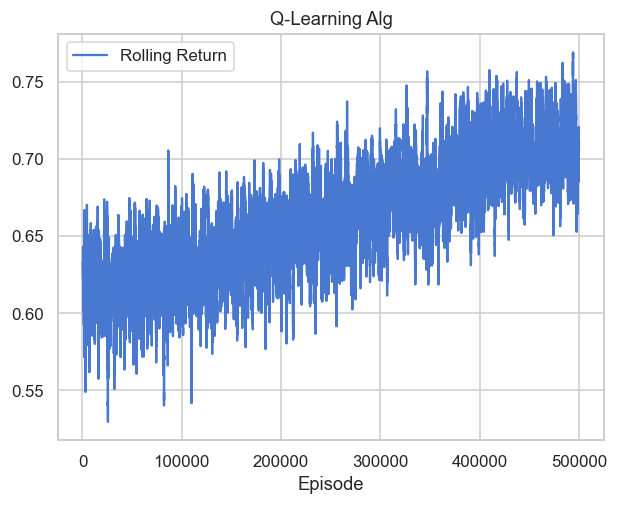

In [49]:
df_return_over_time_sepsis_SARSA['Rolling Return'] = df_return_over_time_sepsis_SARSA['Return'].rolling(500).mean()
df_return_over_time_sepsis_SARSA.plot(x='Episode', y='Rolling Return', title='Q-Learning Alg')

Decreasing the learning rate,alpha, to 0.05 lets the agent learn more slowly, but more stably, since each new experience only slightly adjusts the Q-values, making the learning process cumulative and robust, not changing the treatment completely after one bad outcome.

Based on the rolling average, with a window equal to 500 epsodes, the line shows a consistent upward slope throughout all 500 000 the episodes, starting the firsts episodes in a range of 0.56 to 0.67, approximately, while the lasts episodes between 0.65 to 0.76, significant improvement. This means the agent is genuinely and consistently improving over time, rather than randomly fluctuating.



### Differnt numbers of min_epsilon

In [51]:
results = []
for min_eps in [0.01, 0.05, 0.1]:
    np.random.seed(SEED)
    env = make_sepsis_env()
    Q, df_ret, _, _, _, _ = sepsis_SARSA_q_function(
        env,
        num_iterations=500000,
        alpha=0.05,
        gamma=0.99,
        min_epsilon=min_eps
    )
    policy = np.argmax(Q, axis=1)
    ret, _ = evaluate_policy(policy)
    sr = float(np.mean(ret > 0)) * 100
    print(f"min_epsilon={min_eps}: Survival Rate = {sr:.1f}%")
    results.append([min_eps, sr])

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


Exception ignored in: <function tqdm.__del__ at 0x0000013C30B33370>
Traceback (most recent call last):
  File "c:\Users\PC\anaconda3\envs\reinforcement-learning\lib\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "c:\Users\PC\anaconda3\envs\reinforcement-learning\lib\site-packages\tqdm\notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


KeyboardInterrupt: 

We tested three different minimum epsilon values to tune the exploration vs exploitation balance. The results show that min_epsilon=0.01 achieves the highest survival rate (75%), followed by 0.05 (73.7%) and 0.1 (74.2%). 

This makes sense because a lower min_epsilon allows the agent to exploit its learned Q-values more confidently in later episodes, while still 
maintaining a small 1% exploration rate to avoid getting permanently stuck in a suboptimal policy. Higher min_epsilon values force the agent to keep making random treatment decisions too often, reducing overall performance.

### Let's try ven more iterations

Since we had already changed the number of iterations from 10000 to 500000, we wanted to investigate whether increasing it further would yield better survival rates, so we tested values from 1000000 up to 8000000 in increments of 1000000.

In [52]:
Q_table_sepsis_SARSA, df_return_over_time_sepsis_SARSA, df_steps_over_time_sepsis_SARSA, epsilon_over_time_SARSA, actions_over_time_SARSA,df_checkpoints_SARSA = sepsis_SARSA_q_function(
    env,
    num_iterations=8000000,
    alpha=0.05,
    gamma=0.99,
    checkpoint=False
)


KeyboardInterrupt: 

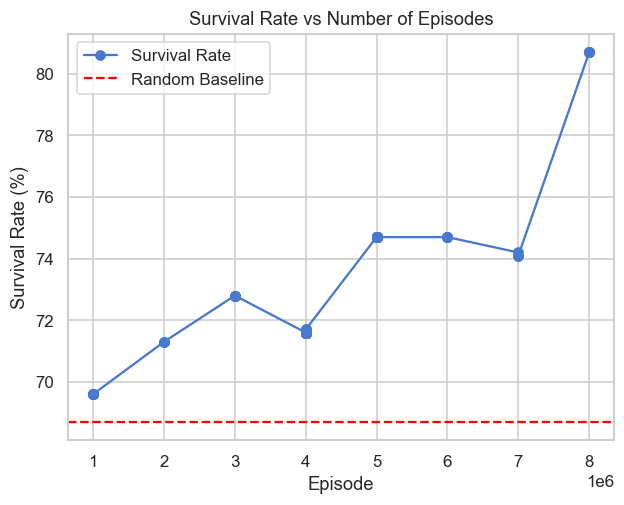

In [ ]:
df_checkpoints_SARSA.plot(x='Episode', y='Survival Rate', marker='o')
plt.axhline(y=68.7, color='red', linestyle='--', label='Random Baseline')
plt.title('Survival Rate vs Number of Episodes')
plt.ylabel('Survival Rate (%)')
plt.xlabel('Episode')
plt.legend()
plt.show()

As we can see, the survival rate generally increases with more episodes, starting at 69.8% at episode 1000000 (barely above the random baseline of 68.7%) and reaching 80.5% at episode 8000000. However, the increase is not perfectly linear, there are dips at episodes 4000000 and 7000000, 
which can be explained by the stochastic nature of both the environment and the evaluation process.

The overall upward trend confirms that more episodes allow the agent to visit more states and refine its Q-values, leading to a more effective treatment policy. The biggest improvement happens between episodes 7000000 and 
8000000.This coincides with epsilon dropping from 0.125 to 0.01 in the final million episodes, the agent transitions from still exploring 12.5% of the time to nearly full exploitation, finally committing to its learned treatment strategy and achieving its best performance.

### Final results

<Axes: title={'center': 'Sarsa Alg'}, xlabel='Episode'>

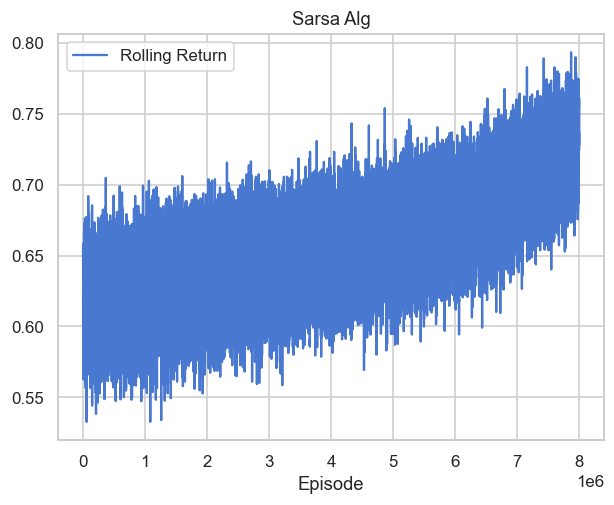

In [ ]:
df_return_over_time_sepsis_SARSA['Rolling Return'] = df_return_over_time_sepsis_SARSA['Return'].rolling(500).mean()
df_return_over_time_sepsis_SARSA.plot(x='Episode', y='Rolling Return',title='Sarsa Alg')

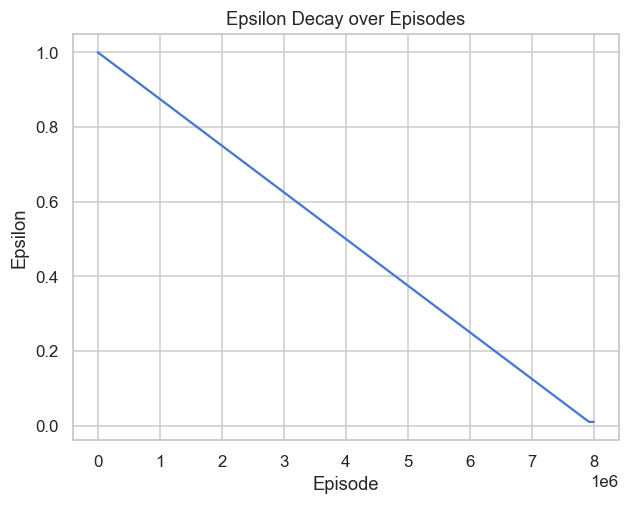

In [ ]:
plt.plot(epsilon_over_time_SARSA)
plt.xlabel('Episode')
plt.ylabel('Epsilon')
plt.title('Epsilon Decay over Episodes')
plt.show()

During the early episodes, the agent is mostly exploring (epsilon close to 1.0), resulting in the lowest rolling returns as it is still in the initial learning phase. Around episode 4000000, it reaches a balance between exploration and exploitation (epsilon = 0.5). From this point onward, the 
agent gradually explores less and exploits more, becoming increasingly confident in its treatment choices which is clearly visible in the rolling return trending upward more steeply in the second half of training. By the end of training, epsilon reaches 0.01, meaning 99% exploitation and only 1% exploration. The agent finishes with approximately 80% of patients surviving across the last 500 episodes.

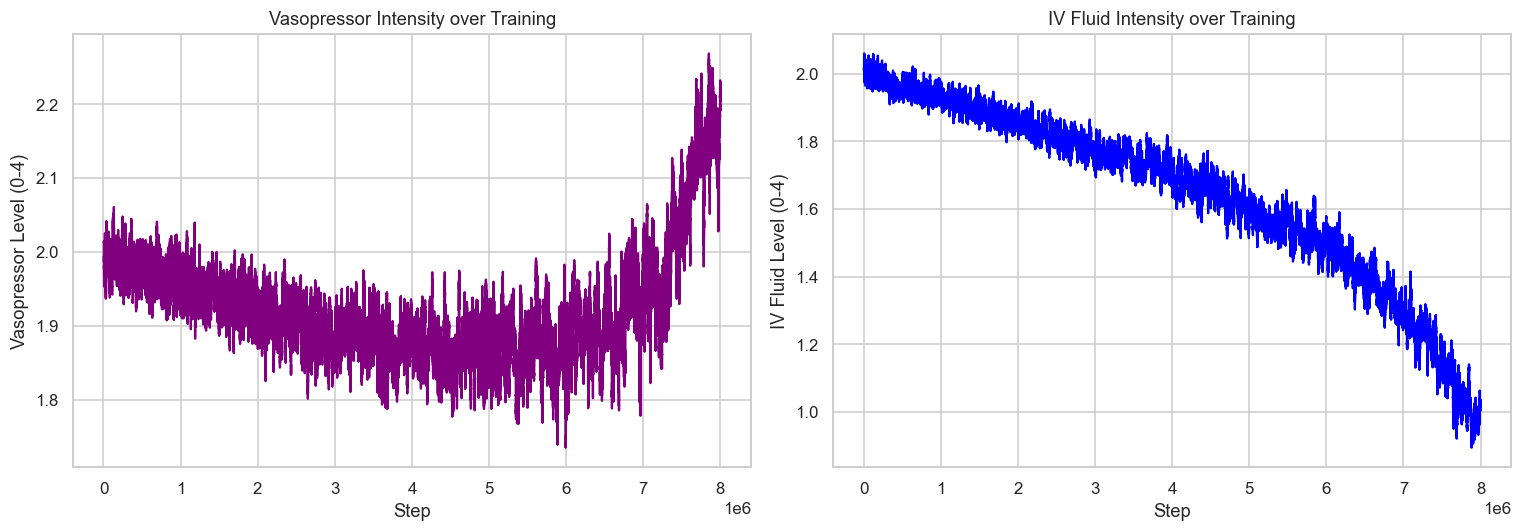

In [ ]:
df_actions = pd.DataFrame({
    'Vasopressor': [a // 5 for a in actions_over_time_SARSA],
    'IV Fluid': [a % 5 for a in actions_over_time_SARSA]
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rolling average of vasopressor level
axes[0].plot(df_actions['Vasopressor'].rolling(5000).mean(), color='purple')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Vasopressor Level (0-4)')
axes[0].set_title('Vasopressor Intensity over Training')

# Rolling average of IV fluid level
axes[1].plot(df_actions['IV Fluid'].rolling(5000).mean(), color='blue')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('IV Fluid Level (0-4)')
axes[1].set_title('IV Fluid Intensity over Training')

plt.tight_layout()
plt.show()

In the treatment intensity graphs, both vasopressor and IV fluid levels start around 2.0, which corresponds to the random average when epsilon is high (average of levels 0-4 = 2.0). As the agent learns the vasopressor level decreases to approximedatly 1 in the episode 6000000 and starts to increase till approximedatly to 2.2. This means when the agent is exploraing he tries with lower vassopressor level, but when the agents starts to do more exploitation the level of vassopressor increases, menaning the agent starts to be more sure that in order the patient to survive the more it needs for vasopressor. <br>
On the contrary, the IV fluid level decresaes along th eepisodes having a more intense decrease when the agent starts to exploit more than explore, from the 4000000 episodes when the epsilon is 0.5.

In conclusion, the agent learned two key treatment strategies: **increase vasopressor levels** to maintain blood pressure, while **decreasing IV fluid** to avoid fluid overload.

In [ ]:
#picks the best action for each state
policy_ql = np.argmax(Q_table_sepsis_SARSA, axis=1)
ret_ql, len_ql = evaluate_policy(policy_ql)

#results :D
print(f"Survival Rate  : {float(np.mean(ret_ql > 0)) * 100:.1f}%")
print(f"Mean Return    : {np.mean(ret_ql):.4f}")
print(f"Mean Ep Length : {np.mean(len_ql):.1f}")

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Survival Rate  : 80.7%
Mean Return    : 0.7211
Mean Ep Length : 11.2


In [ ]:
policy_ql = np.argmax(Q_table_sepsis, axis=1)

agree_rate = float(np.mean(policy_ql == policy_pi)) * 100
print(f"Policy agreement with PI: {agree_rate:.1f}%")

Policy agreement with PI: 37.4%


The final hyperparemetrs values were:

| Property | SARSA 
|---|---|
| num_iterations | 8000000 |
| alpha | 0.01 | 
| gamma | 0.99|
|min_epsilon|0.01|

The survival rate achivied was 80.7%, clearly beating the random baseline of 68.7%. The mean return was 0.7211, which is lower than the survival rate due to the accumulated intensity penalties (lambda=0.02) for unnecessary treatment at each step.

The policy agreement with PI is 37.4%, which shows that Q-Learning found different actions that lead to similar outcomes. This suggests that in the sepsis environment multiple effective treatment strategies exist, and Q-Learning was able to discover one of them purely from experience, without access to the transition model.
  

## Creative Extension: Effect of Treatment Penalty λ

The creative extension investigates how changing the treatment intensity penalty λ affects the learned policy in Configuration A.

In the original environment, λ = 0.02. This penalty discourages unnecessary treatment intensity. We test several λ values:

- 0.01: weaker penalty
- 0.02: default penalty
- 0.05 and 0.10: stronger penalties
- 0.50: very strong penalty

The objective is to analyse whether increasing the penalty makes the agent more conservative and how this affects survival rate, mean return, and episode length.

## 5.1 Policy Iteration

Policy Iteration is used to compute the optimal policy directly from the known
transition and reward matrices of the environment.

For each λ value:

1. A new environment is created.
2. The reward matrix is rebuilt using the corresponding treatment penalty.
3. Policy Iteration is executed.
4. The resulting policy is evaluated over 1000 episodes.

The goal is to observe how increasing treatment penalties influence the optimal
decision-making strategy.

In [53]:
lam_values = [0.01, 0.02, 0.05, 0.1, 0.5]
results_lam = []

for lam in lam_values:
    env_test = make_sepsis_env(lam=lam)
    raw_test = env_test.unwrapped
    P_test = raw_test._tx_mat
    R_test = (P_test * raw_test._r_mat).sum(axis=2)
    env_test.close()

    V_test, policy_test, _ = policy_iteration(P_test, R_test, gamma=GAMMA)

    np.random.seed(SEED)
    env_eval = make_sepsis_env(lam=lam)
    returns, lengths = [], []
    for _ in range(1000):
        obs, _ = env_eval.reset(seed=np.random.randint(100_000))
        total_r, steps, done = 0.0, 0, False
        while not done:
            action = int(policy_test[int(obs)])
            obs, r, te, tr, _ = env_eval.step(action)
            total_r += r; steps += 1; done = te or tr
        returns.append(total_r)
        lengths.append(steps)
    env_eval.close()

    results_lam.append({
        'lam': lam,
        'survival_rate': float(np.mean(np.array(returns) > 0)) * 100,
        'mean_ep_length': float(np.mean(lengths)),
        'unique_actions': len(np.unique(policy_test))
    })

df_lam = pd.DataFrame(results_lam)
print("=== Effect of lam on survival rate (Policy Iteration) ===")
print(df_lam.to_string(index=False))

make_sepsis_env | lam=0.01 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.01 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.05 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.05 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.1 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.1 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.5 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_e

### Policy Iteration Results

The results show that increasing λ gradually reduces survival performance.

| λ | Survival Rate (%) | Mean Episode Length | Unique Actions |
|---|---|---|---|
|0.01|79.6|10.61|20|
|0.02|78.8|9.81|15|
|0.05|73.9|9.19|10|
|0.10|70.3|9.57|6|
|0.50|68.5|9.87|2|

Several observations can be made:

- Survival rate decreases as λ increases.
- Larger penalties lead to simpler policies.
- The number of unique actions decreases from 20 to only 2.
- High λ values encourage conservative treatment behaviour.
- Despite this simplification, survival remains relatively high.

## 5.2 SARSA

Unlike Policy Iteration, SARSA learns a policy through interaction with the
environment.

To keep computational requirements manageable, SARSA is trained for only
1000 episodes for each λ value.

For every λ:

1. A new environment is created.
2. SARSA learns a Q-table.
3. A greedy policy is extracted from the learned Q-values.
4. The resulting policy is evaluated over 1000 episodes.

This experiment analyses whether the learned behaviour changes as treatment
penalties become stronger.

In [54]:
lam_values = [0.01, 0.02, 0.05, 0.1, 0.5]
results_lam_sarsa = []

for lam in lam_values:
    print("=" * 60)
    print(f"Training SARSA with lam={lam}")
    print("=" * 60)

    # Create training environment with this lambda value
    env_train = make_sepsis_env(lam=lam)

    # Train SARSA with only 1000 iterations
    Q_table_sarsa, df_return_sarsa, df_steps_sarsa, epsilon_sarsa, actions_sarsa, df_checkpoints_sarsa = sepsis_SARSA_q_function(
        env_train,
        num_iterations=1000,
        alpha=0.05,
        gamma=0.99,
        checkpoint=False
    )

    env_train.close()

    # Convert learned Q-table into a deterministic greedy policy
    policy_sarsa = np.argmax(Q_table_sarsa, axis=1)

    # Evaluate learned SARSA policy
    np.random.seed(SEED)
    env_eval = make_sepsis_env(lam=lam)

    returns, lengths = [], []

    for _ in range(1000):
        obs, _ = env_eval.reset(seed=np.random.randint(100_000))
        obs = int(obs)

        total_r, steps, done = 0.0, 0, False

        while not done:
            action = int(policy_sarsa[obs])

            obs, r, terminated, truncated, _ = env_eval.step(action)
            obs = int(obs)

            total_r += r
            steps += 1
            done = terminated or truncated

        returns.append(total_r)
        lengths.append(steps)

    env_eval.close()

    results_lam_sarsa.append({
        "lam": lam,
        "survival_rate": float(np.mean(np.array(returns) > 0)) * 100,
        "mean_return": float(np.mean(returns)),
        "mean_ep_length": float(np.mean(lengths)),
        "unique_actions": len(np.unique(policy_sarsa))
    })

df_lam_sarsa = pd.DataFrame(results_lam_sarsa)

print("=== Effect of lam on survival rate (SARSA, 1000 iterations) ===")
print(df_lam_sarsa.to_string(index=False))

Training SARSA with lam=0.01
make_sepsis_env | lam=0.01 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.01 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Training SARSA with lam=0.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Training SARSA with lam=0.05
make_sepsis_env | lam=0.05 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.05 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Training SARSA with lam=0.1
make_sepsis_env | lam=0.1 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.1 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Trainin

### SARSA Results

| λ | Survival Rate (%) | Mean Return | Mean Episode Length | Unique Actions |
|---|---|---|---|---|
|0.01|69.1|0.662|10.13|25|
|0.02|69.7|0.646|9.62|25|
|0.05|68.6|0.576|9.92|25|
|0.10|67.5|0.462|10.07|25|
|0.50|50.2|-0.038|9.77|25|

The effect of λ on SARSA differs from Policy Iteration:

- Small and moderate penalties have limited impact on survival.
- Survival remains close to 70% for λ ≤ 0.10.
- A very strong penalty (λ = 0.50) causes a substantial performance drop.
- Unlike Policy Iteration, SARSA continues to use all available actions.
- The learned policy appears less sensitive to λ when trained for only 1000 episodes.